# Machine Learning 2025/2026

### Group no. 05 - David Silva no. 53755  / Luís Reis no. 64409 / Tiago Pereira no. 55854 

# ML Project  - Learning about Donations

## Task 0 - Exploratory Data Analysis

### Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 0.1. Loading Data

In [2]:
df_donors = pd.read_csv('Donors_dataset.csv')

In [ ]:
# Data Set Visualization
df_donors.head()

,TARGET_B,TARGET_D,CONTROL_NUMBER,MONTHS_SINCE_ORIGIN,DONOR_AGE,IN_HOUSE,URBANICITY,SES,CLUSTER_CODE,HOME_OWNER,...,LIFETIME_GIFT_RANGE,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LAST_GIFT_AMT,CARD_PROM_12,NUMBER_PROM_12,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_FIRST_GIFT,FILE_AVG_GIFT,FILE_CARD_GIFT
0,0,NaN,5,101,87.0,0,?,?,.,H,...,15.0,20.0,5.0,15.0,5,12,26,92,8.49,7
1,1,10.0,12,137,79.0,0,R,2,45,H,...,20.0,25.0,5.0,17.0,7,21,7,122,14.72,12
2,0,NaN,37,113,75.0,0,S,1,11,H,...,23.0,28.0,5.0,19.0,11,32,6,105,16.75,16
3,0,NaN,38,92,NaN,0,U,2,4,H,...,14.0,17.0,3.0,15.0,11,33,6,92,11.76,12
4,0,NaN,41,101,74.0,0,R,2,49,U,...,20.0,25.0,5.0,25.0,6,19,18,92,8.83,3


In [ ]:
# Data Structure Verification
print(f'df_donors')
print({df_donors.info()})

df_donors
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19372 entries, 0 to 19371
Data columns (total 50 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   TARGET_B                     19372 non-null  int64  
 1   TARGET_D                     4843 non-null   float64
 2   CONTROL_NUMBER               19372 non-null  int64  
 3   MONTHS_SINCE_ORIGIN          19372 non-null  int64  
 4   DONOR_AGE                    14577 non-null  float64
 5   IN_HOUSE                     19372 non-null  int64  
 6   URBANICITY                   19372 non-null  object 
 7   SES                          19372 non-null  object 
 8   CLUSTER_CODE                 19372 non-null  object 
 9   HOME_OWNER                   19372 non-null  object 
 10  DONOR_GENDER                 19372 non-null  object 
 11  INCOME_GROUP                 14980 non-null  float64
 12  PUBLISHED_PHONE              19372 non-null  int64  
 13  OVERLA

## 0.2. Understanding Data

In this task you should **understand better the features**, their distribution of values, potential errors, etc and plan/describe what data preprocessing steps should be performed next. Very important also is the distribution of values in the target (class distribution). 

Here you can find a notebook with some examples of what you can do in **Exploratory Data Analysis**: https://www.kaggle.com/artgor/exploration-of-data-step-by-step/notebook. You can also use Orange widgets for this.

In [ ]:
# Statistical Summary
print(df_donors.describe())

           TARGET_B     TARGET_D  CONTROL_NUMBER  MONTHS_SINCE_ORIGIN  \
count  19372.000000  4843.000000    19372.000000         19372.000000   
mean       0.250000    15.624344    96546.225377            73.409973   
std        0.433024    12.445137    55830.643871            41.255574   
min        0.000000     1.000000        5.000000             5.000000   
25%        0.000000    10.000000    48289.000000            29.000000   
50%        0.000000    13.000000    96937.000000            65.000000   
75%        0.250000    20.000000   145429.500000           113.000000   
max        1.000000   200.000000   191779.000000           137.000000   

          DONOR_AGE      IN_HOUSE  INCOME_GROUP  PUBLISHED_PHONE  \
count  14577.000000  19372.000000  14980.000000     19372.000000   
mean      58.919051      0.073198      3.907543         0.497729   
std       16.669382      0.260469      1.864796         0.500008   
min        0.000000      0.000000      1.000000         0.000000   
25

In [ ]:
# Missing Data Identification (Null Values Check)
missing_data = df_donors.isnull().sum()
print(missing_data[missing_data > 0])

TARGET_D                       14529
DONOR_AGE                       4795
INCOME_GROUP                    4392
WEALTH_RATING                   8810
MONTHS_SINCE_LAST_PROM_RESP      246
dtype: int64


In [5]:
# Frequency Distribution of 'URBANICITY' Column (Categorical Variable Analysis)
print(df_donors['URBANICITY'].value_counts())

URBANICITY
S    4491
C    4022
R    4005
T    3944
U    2456
?     454
Name: count, dtype: int64


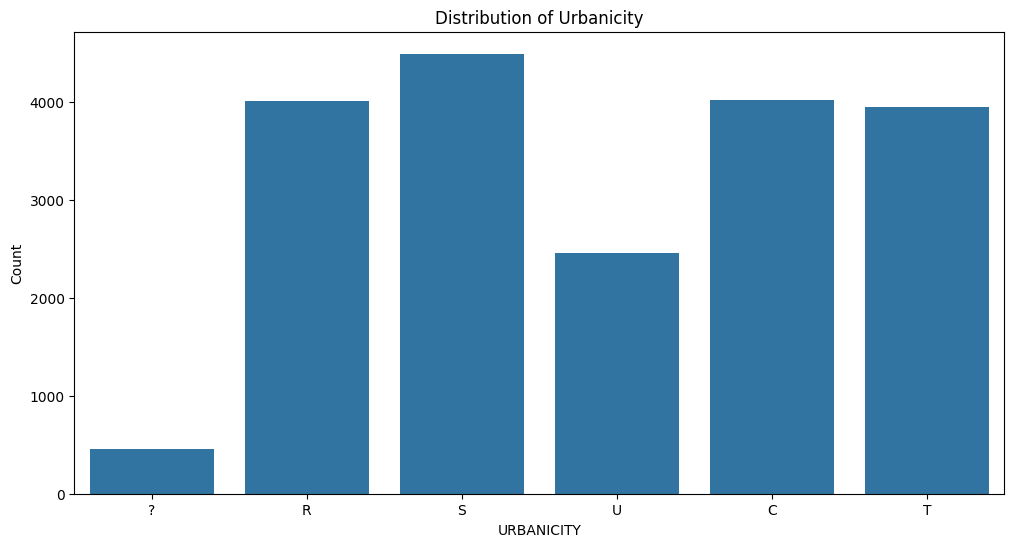

In [ ]:
# Visualization of URBANICITY Distribution

# Set the figure size
plt.figure(figsize=(12, 6))
# Create a count plot for the URBANICITY variable
sns.countplot(data=df_donors, x='URBANICITY')
# Set the title and labels
plt.title('Distribution of Urbanicity')
plt.ylabel('Count')
# Display the plot
plt.show()

In [7]:
# Frequency Distribution of 'SES' Column (Categorical Variable Analysis)
print(df_donors['SES'].value_counts())

SES
2    9284
1    5924
3    3323
?     454
4     387
Name: count, dtype: int64


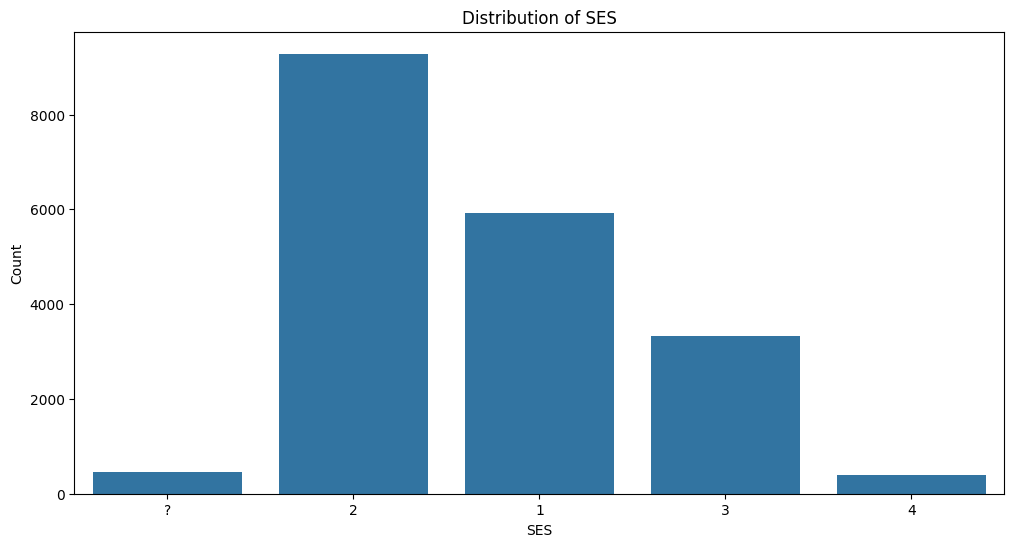

In [ ]:
# Visualization of SES Distribution

# Set the figure size
plt.figure(figsize=(12, 6))
# Create a count plot for the SES variable
sns.countplot(data=df_donors, x='SES')
# Set the title and labels
plt.title('Distribution of SES')
plt.ylabel('Count')
# Display the plot
plt.show()

In [14]:
# Frequency Distribution of 'DONOR_GENDER' Column (Categorical Variable Analysis)
print(df_donors['DONOR_GENDER'].value_counts())

DONOR_GENDER
F    10401
M     7953
U     1017
A        1
Name: count, dtype: int64


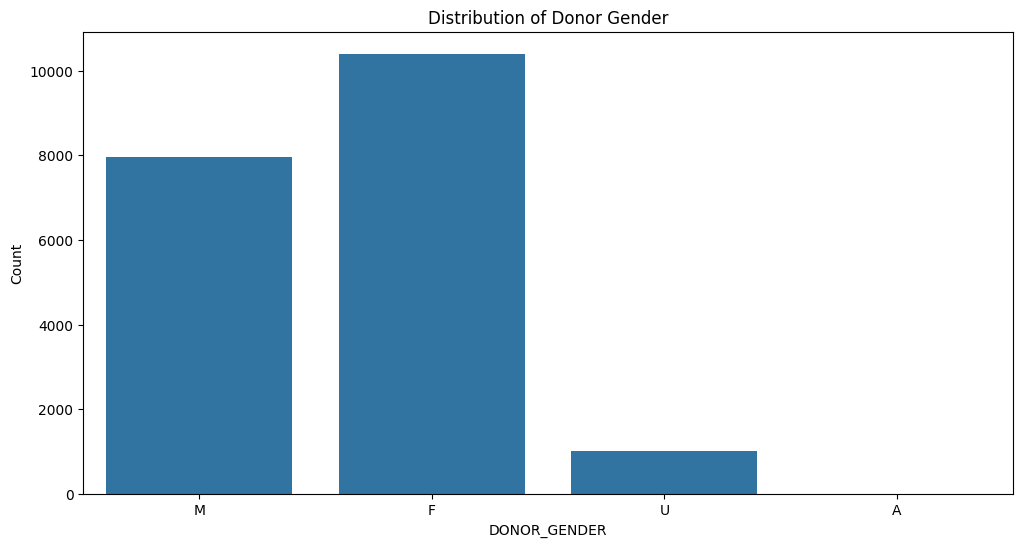

In [15]:
# Visualization of DONOR_GENDER Distribution

# Set the figure size
plt.figure(figsize=(12, 6))
# Create a count plot for the DONOR
sns.countplot(data=df_donors, x='DONOR_GENDER')
# Set the title and labels
plt.title('Distribution of Donor Gender')
plt.ylabel('Count')
# Display the plot
plt.show()

In [12]:
# Frequency Distribution of 'HOME_OWNER' Column (Categorical Variable Analysis)
print(df_donors['HOME_OWNER'].value_counts())

HOME_OWNER
H    10606
U     8766
Name: count, dtype: int64


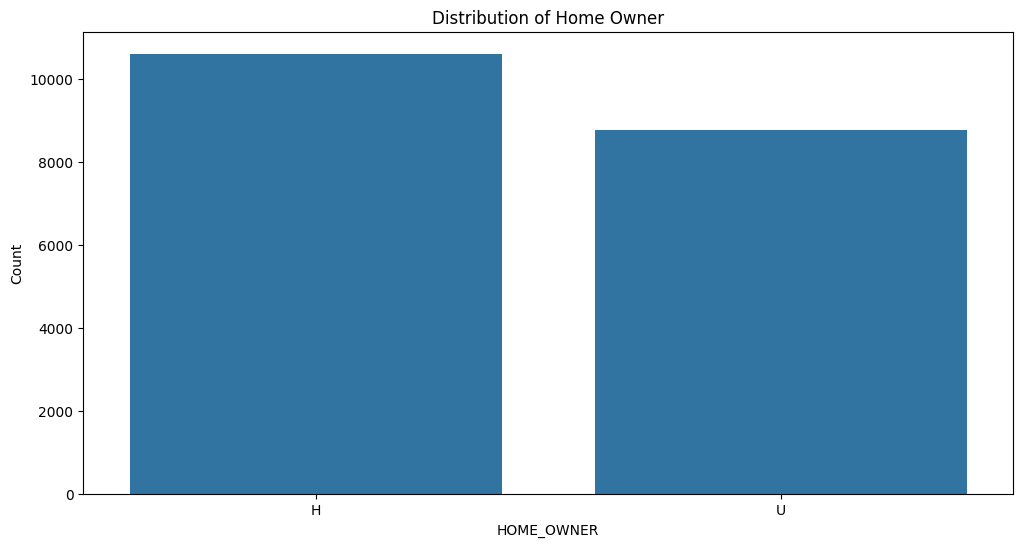

In [13]:
# Visualization of HOME_OWNER Distribution

# Set the figure size
plt.figure(figsize=(12, 6))
# Create a count plot for the HOME_OWNER variable
sns.countplot(data=df_donors, x='HOME_OWNER')
# Set the title and labels
plt.title('Distribution of Home Owner')
plt.ylabel('Count')
# Display the plot
plt.show()

In [16]:
# Frequency Distribution of 'OVERLAY_SOURCE' Column (Categorical Variable Analysis)
print(df_donors['OVERLAY_SOURCE'].value_counts())

OVERLAY_SOURCE
B    8732
P    4768
N    4392
M    1480
Name: count, dtype: int64


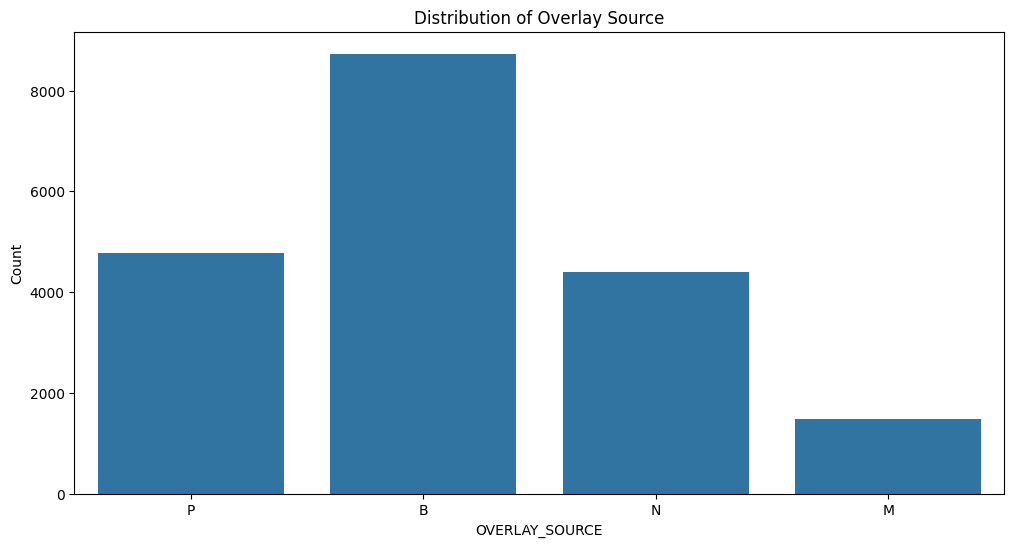

In [17]:
# Visualization of OVERLAY_SOURCE Distribution

# Set the figure size
plt.figure(figsize=(12, 6))
# Create a count plot for the OVERLAY_SOURCE variable
sns.countplot(data=df_donors, x='OVERLAY_SOURCE')
# Set the title and labels
plt.title('Distribution of Overlay Source')
plt.ylabel('Count')
# Display the plot
plt.show()

In [10]:
# Frequency Distribution of 'CLUSTER_CODE' Column (Categorical Variable Analysis)
print(df_donors['CLUSTER_CODE'].value_counts())

CLUSTER_CODE
40    830
24    795
35    727
36    716
49    675
27    666
12    631
18    619
13    579
30    519
39    512
11    484
45    482
43    468
51    460
.     454
14    454
41    431
10    387
16    384
44    383
2     380
8     378
46    369
21    353
17    349
28    343
20    317
53    303
3     300
23    293
34    284
42    284
25    273
22    251
31    249
38    240
1     239
15    223
37    204
26    202
5     199
47    185
7     184
48    180
29    170
50    156
9     153
32    152
6     123
4     113
33    109
19     98
52     60
Name: count, dtype: int64


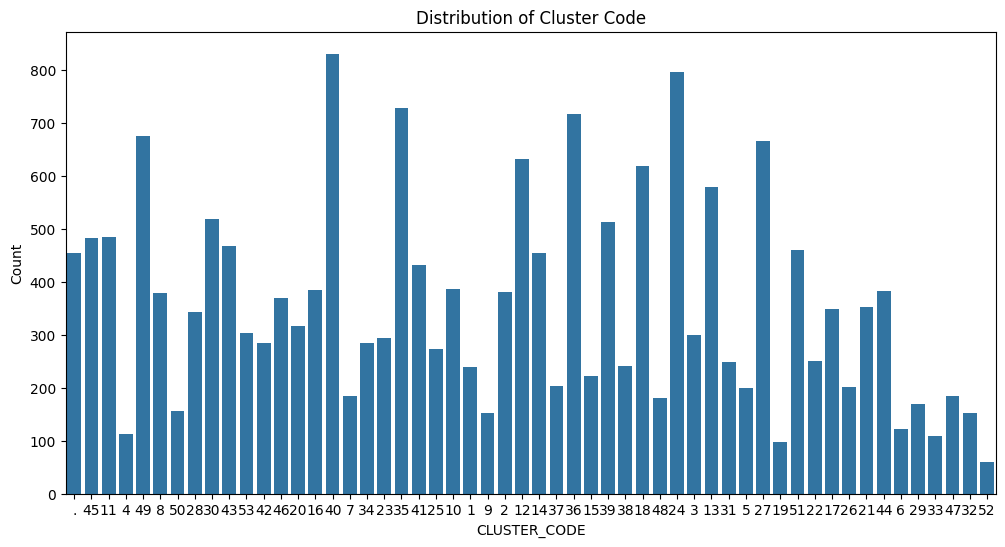

In [11]:
# Visualization of CLUSTER_CODE Distribution

# Set the figure size
plt.figure(figsize=(12, 6))
# Create a count plot for the CLUSTER_CODE variable
sns.countplot(data=df_donors, x='CLUSTER_CODE')
# Set the title and labels
plt.title('Distribution of Cluster Code')
plt.ylabel('Count')
# Display the plot
plt.show()

In [18]:
# Frequency Distribution of 'RECENCY_STATUS_96NK' Column (Categorical Variable Analysis)
print(df_donors['RECENCY_STATUS_96NK'].value_counts())

RECENCY_STATUS_96NK
A    11918
S     4221
F     1521
N     1192
E      427
L       93
Name: count, dtype: int64


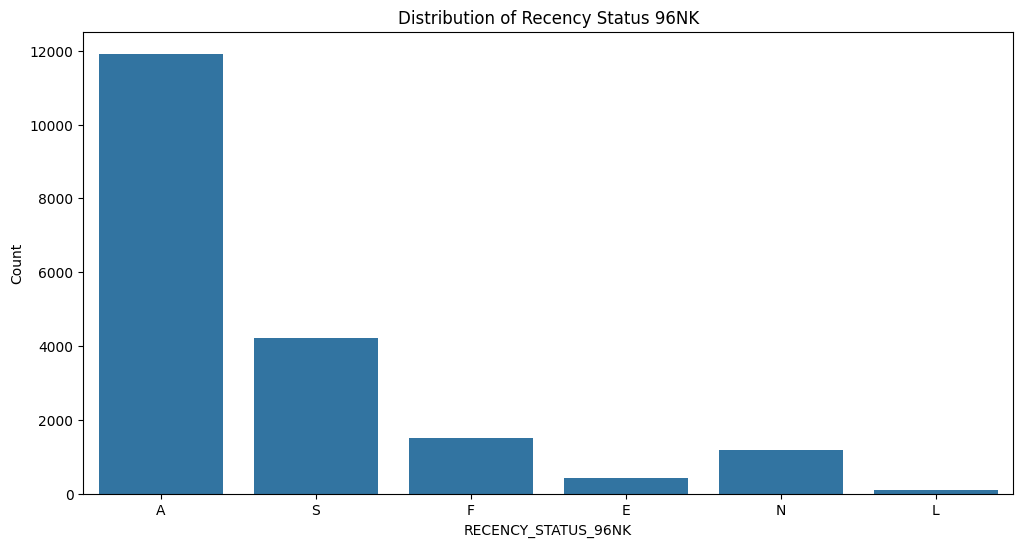

In [19]:
# Visualization of RECENCY_STATUS_96NK Distribution

# Set the figure size
plt.figure(figsize=(12, 6))
# Create a count plot for the RECENCY_STATUS_96NK variable
sns.countplot(data=df_donors, x='RECENCY_STATUS_96NK')
# Set the title and labels
plt.title('Distribution of Recency Status 96NK')
plt.ylabel('Count')
# Display the plot
plt.show()

In [ ]:
# Frequency Distribution of 'FREQUENCY_STATUS_97NK' Column (Categorical Variable Analysis)
print(df_donors['FREQUENCY_STATUS_97NK'].value_counts())

FREQUENCY_STATUS_97NK
1    9118
2    4191
3    3318
4    2745
Name: count, dtype: int64


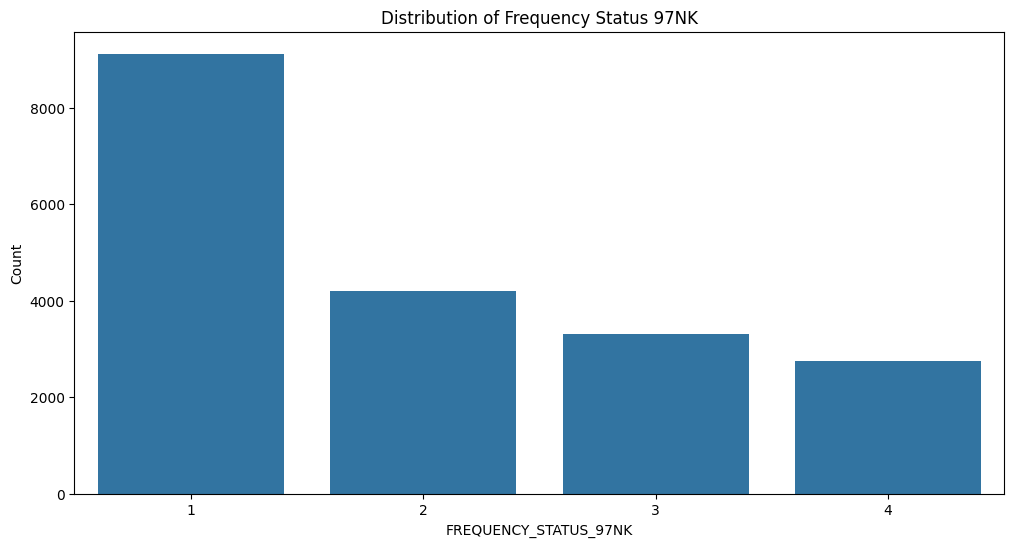

In [23]:
# Visualization of FREQUENCY_STATUS_97NK Distribution~

# Set the figure size
plt.figure(figsize=(12, 6))
# Create a count plot for the FREQUENCY_STATUS_97NK variable
sns.countplot(data=df_donors, x='FREQUENCY_STATUS_97NK')
# Set the title and labels
plt.title('Distribution of Frequency Status 97NK')
plt.ylabel('Count')
# Display the plot
plt.show()

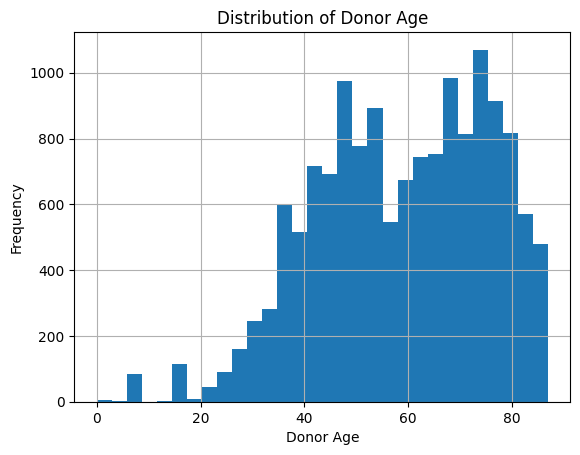

In [ ]:
# Visualization of DONOR_AGE Distribution (Continuous Variable Analysis)
df_donors['DONOR_AGE'].hist(bins=30)
plt.xlabel('Donor Age')
plt.ylabel('Frequency')
plt.title('Distribution of Donor Age')
plt.show()

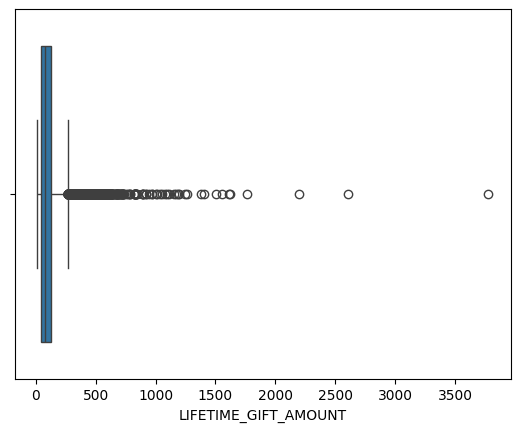

In [ ]:
# Boxplot of LIFETIME_GIFT_AMOUNT to Identify Outliers
sns.boxplot(x='LIFETIME_GIFT_AMOUNT', data=df_donors)
plt.show()

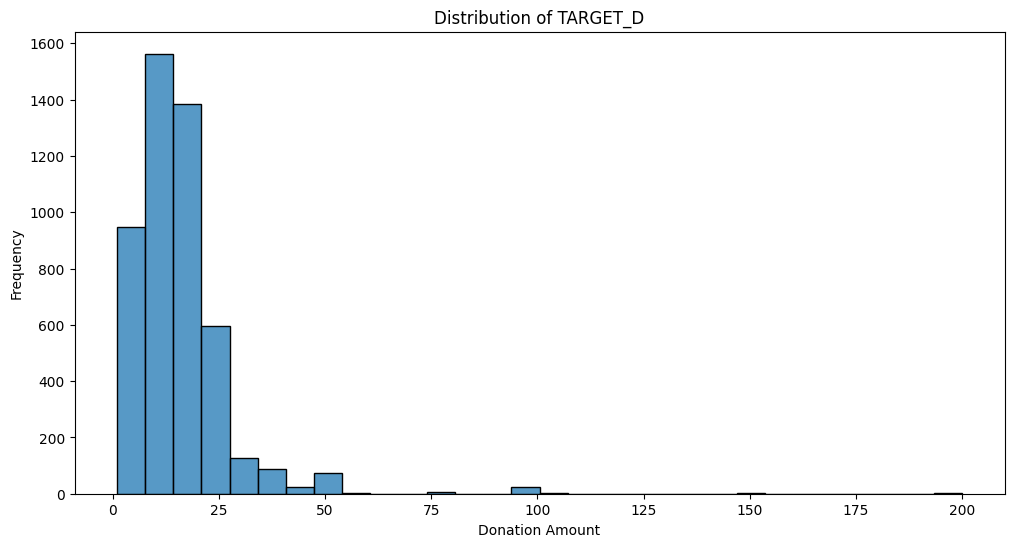

In [11]:
# Visualization of TARGET_D Distribution
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size
plt.figure(figsize=(12, 6))

# Create a histogram for the TARGET_D variable
sns.histplot(df_donors['TARGET_D'].dropna(), bins=30)

# Set the title and labels
plt.title('Distribution of TARGET_D')
plt.xlabel('Donation Amount')
plt.ylabel('Frequency')

# Display the plot
plt.show()

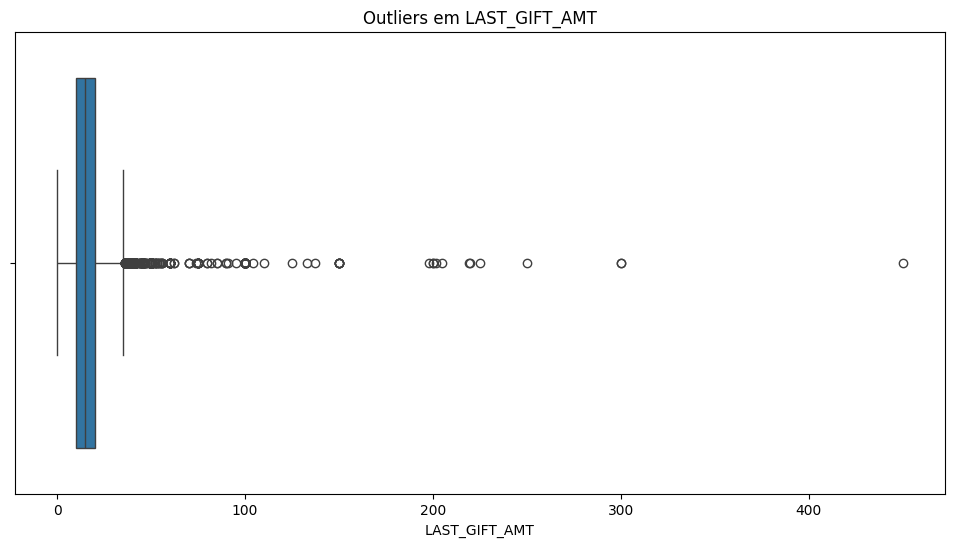

In [ ]:
# Outlier Detection in LAST_GIFT_AMT
plt.figure(figsize=(12, 6))
sns.boxplot(x=df_donors['LAST_GIFT_AMT'])
plt.title('Outliers em LAST_GIFT_AMT')
plt.show()

...

...

## Task 1 (Supervised Learning) - Predicting Donation and Donation Type

In this task you should target 2 classification tasks:
1. **Predicting Donation (binary classification task)** 
2. **Predicting Donation TYPE (multiclass classification)**

## 1.1. Specific Data Preprocessing for Classification

## 1.2. Learning and Evaluating Classifiers

...

## 1.3. Classification - Final Discussion and Conclusions 

...

## Task 2 (Unsupervised Learning) - Characterizing Donors and Donation Type

In this task you should **use unsupervised learning to characterize donors (people who really did a donation) and their donation type**.
1. **Use clustering algorithms to find similar groups of donors**. Is it possible to find groups of donors with the same/similar DonationTYPE? Evaluate clustering results using **internal and external metrics**.
2. **Be creative and define and explore your own clustering task!** What else would it be interesting to find out?

## 2.1. Preprocessing Data for Clustering

...

## 2.2. Learning and Evaluating Clusterings

...

## 2.3. Clustering - Final Discussion and Conclusions

...

## 3. Final Comments and Conclusions

...